# STTP-Net: Long-Tail Skin Lesion Classification on HAM10000

**Pipeline**: Pretrained Encoder → CVAE + SupCon → Class Grouping → Tail-Aware Samplers → HybridMix → Dual-Head Classifier → EBS Loss → Fused Prediction

| Class | Label | ~Count | Group |
|-------|-------|--------|-------|
| Melanocytic nevi | nv | 6705 | **Head** |
| Melanoma | mel | 1113 | **Median** |
| Benign keratosis | bkl | 1099 | **Median** |
| Basal cell carcinoma | bcc | 514 | **Tail** |
| Actinic keratosis | akiec | 327 | **Tail** |
| Vascular lesions | vasc | 142 | **Tail** |
| Dermatofibroma | df | 115 | **Tail** |

---
**Run all cells top-to-bottom.** Only change needed: `BASE_DIR` in Cell 1.

## 0. Install (run once, then comment out)

In [ ]:
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118
# !pip install timm pandas numpy scikit-learn matplotlib seaborn tqdm

In [ ]:
import sys
print(sys.executable)

d:\anaconda\envs\sttp_net\python.exe


## 1. Imports + Paths + Config  ← only edit BASE_DIR here

In [1]:
# ── Standard imports ──────────────────────────────────────────────────────────
import os, random, warnings, json, copy
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from matplotlib.patches import Patch

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.metrics import (classification_report, confusion_matrix,
                              balanced_accuracy_score, roc_auc_score)
from sklearn.preprocessing import label_binarize
from tqdm import tqdm

# ── Seed ──────────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# ── PATHS  <--- UPDATE THIS TO YOUR FOLDER ────────────────────────────────────
BASE_DIR  = r'D:\class imbalance\date-16'   # <-- right-click DATE-16 in VS Code → Copy Path

DATA_DIR  = os.path.join(BASE_DIR, 'data')
RAW_DIR   = os.path.join(DATA_DIR, 'raw')
IMAGE_DIR = os.path.join(RAW_DIR,  'images')
META_PATH = os.path.join(RAW_DIR,  'metadata.csv')
SPLIT_DIR = os.path.join(DATA_DIR, 'splits')
TRAIN_CSV = os.path.join(SPLIT_DIR, 'train.csv')
VAL_CSV   = os.path.join(SPLIT_DIR, 'val.csv')
TEST_CSV  = os.path.join(SPLIT_DIR, 'test.csv')
CKPT_DIR  = os.path.join(BASE_DIR,  'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)

# ── Hyperparameters ───────────────────────────────────────────────────────────
IMG_SIZE      = 224
BATCH_SIZE    = 16
NUM_WORKERS   = 0
ENCODER_DIM   = 512
LATENT_DIM    = 128
NUM_CLASSES   = 7
LR            = 3e-4
WEIGHT_DECAY  = 1e-4
EPOCHS_PHASE1 = 35    # HybridMix phase
EPOCHS_PHASE2 = 10    # Boundary refinement phase
TEMPERATURE   = 0.07
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Class metadata ────────────────────────────────────────────────────────────
CLASS_NAMES = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']
LABEL2IDX   = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX2LABEL   = {i: c for c, i in LABEL2IDX.items()}
HEAD_THRESH = 1000    # freq > 1000  → head
TAIL_THRESH = 600     # freq < 500   → tail
COLORS      = {'head': '#2ecc71', 'median': '#f39c12', 'tail': '#e74c3c'}

# ── Sanity check ──────────────────────────────────────────────────────────────
print(f'Device       : {DEVICE}')
print(f'BASE_DIR     : {BASE_DIR}')
print(f'metadata.csv : {os.path.exists(META_PATH)}')
print(f'train.csv    : {os.path.exists(TRAIN_CSV)}')
print(f'images dir   : {os.path.exists(IMAGE_DIR)}')
assert os.path.exists(META_PATH), 'metadata.csv not found — check BASE_DIR'
print('All paths OK.')

Device       : cuda
BASE_DIR     : D:\class imbalance\date-16
metadata.csv : True
train.csv    : True
images dir   : True
All paths OK.


## 2. Load Data & EDA

In [2]:
def load_splits():
    if os.path.exists(TRAIN_CSV):
        print('Loading existing split CSVs ...')
        tr = pd.read_csv(TRAIN_CSV)
        va = pd.read_csv(VAL_CSV)
        te = pd.read_csv(TEST_CSV)
    else:
        print('No splits found — creating from metadata.csv ...')
        from sklearn.model_selection import train_test_split
        meta = pd.read_csv(META_PATH)
        tr, tmp = train_test_split(meta, test_size=0.30, stratify=meta['dx'], random_state=SEED)
        va, te  = train_test_split(tmp,  test_size=0.50, stratify=tmp['dx'],  random_state=SEED)
        os.makedirs(SPLIT_DIR, exist_ok=True)
        tr.to_csv(TRAIN_CSV, index=False)
        va.to_csv(VAL_CSV,   index=False)
        te.to_csv(TEST_CSV,  index=False)
        print(f'Splits saved.')
    for df in [tr, va, te]:
        if 'label_idx' not in df.columns:
            df['label_idx'] = df['dx'].map(LABEL2IDX)
    print(f'train={len(tr)}, val={len(va)}, test={len(te)}')
    return tr, va, te

train_df, val_df, test_df = load_splits()

Loading existing split CSVs ...
train=8012, val=1001, test=1002


Class groups:
  nv      :  5364  [head]
  mel     :   890  [median]
  bkl     :   879  [median]
  bcc     :   411  [tail]
  akiec   :   262  [tail]
  vasc    :   114  [tail]
  df      :    92  [tail]


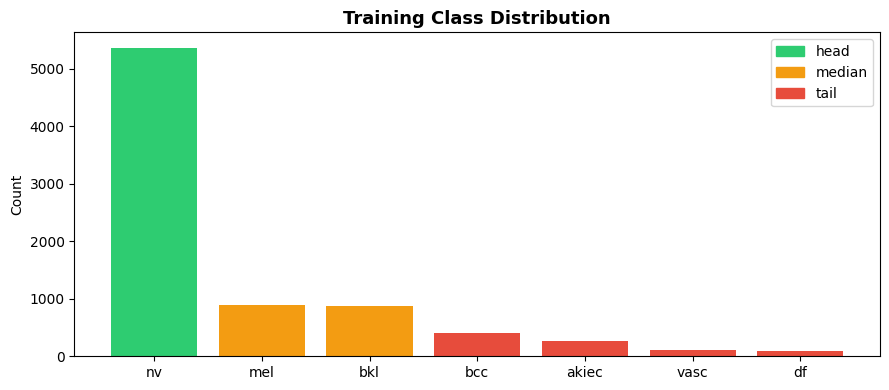

In [3]:
class_counts = Counter(train_df['dx'])

def assign_group(cls):
    n = class_counts[cls]
    if n > HEAD_THRESH: return 'head'
    if n < TAIL_THRESH: return 'tail'
    return 'median'

CLASS_GROUPS   = {c: assign_group(c) for c in CLASS_NAMES}
TAIL_CLASSES   = [c for c, g in CLASS_GROUPS.items() if g == 'tail']
MEDIAN_CLASSES = [c for c, g in CLASS_GROUPS.items() if g == 'median']
HEAD_CLASSES   = [c for c, g in CLASS_GROUPS.items() if g == 'head']

print('Class groups:')
for c in CLASS_NAMES:
    print(f'  {c:8s}: {class_counts[c]:5d}  [{CLASS_GROUPS[c]}]')

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(CLASS_NAMES, [class_counts[c] for c in CLASS_NAMES],
       color=[COLORS[CLASS_GROUPS[c]] for c in CLASS_NAMES])
ax.set_title('Training Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.legend(handles=[Patch(color=v, label=k) for k, v in COLORS.items()])
plt.tight_layout(); plt.show()

## 3. Dataset & Transforms

In [4]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

class AlbumentationsTransform:
    def __init__(self, transform):
        self.transform = transform
    def __call__(self, img):
        img = np.array(img)
        return self.transform(image=img)['image']

# ImageNet normalization — NEVER change this with pretrained ResNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Safe train augmentation for head classes
train_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Rotate(limit=25, p=0.6),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.05,
        rotate_limit=0,
        p=0.4
    ),
    A.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.02,      # very conservative — preserves color diagnostics
        p=0.6
    ),
    A.RandomGamma(gamma_limit=(90, 110), p=0.3),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

# Stronger aug for tail + median (mel, bkl, bcc, akiec, vasc, df)
tail_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.7),
    A.Rotate(limit=35, p=0.7),
    A.ShiftScaleRotate(
        shift_limit=0.07,
        scale_limit=0.07,
        rotate_limit=0,
        p=0.5
    ),
    A.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.03,      # still very conservative
        p=0.7
    ),
    A.RandomGamma(gamma_limit=(85, 115), p=0.4),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_transform = AlbumentationsTransform(train_aug)
tail_transform  = AlbumentationsTransform(tail_aug)

class HAMDataset(Dataset):
    def __init__(self, df, transform=None, tail_transform=None):
        self.df             = df.reset_index(drop=True)
        self.transform      = transform
        self.tail_transform = tail_transform

    def _path(self, image_id):
        for ext in ('.jpg', '.jpeg', '.png'):
            p = os.path.join(IMAGE_DIR, image_id + ext)
            if os.path.exists(p): return p
        raise FileNotFoundError(f'{image_id} not found in {IMAGE_DIR}')

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(self._path(row['image_id'])).convert('RGB')
        label = int(row['label_idx'])
        cls   = IDX2LABEL[label]
        if self.tail_transform and CLASS_GROUPS.get(cls) in ('tail', 'median'):
            img = self.tail_transform(img)
        elif self.transform:
            img = self.transform(img)
        return img, label

train_ds = HAMDataset(train_df, transform=train_transform, tail_transform=tail_transform)
val_ds   = HAMDataset(val_df,   transform=eval_transform)
test_ds  = HAMDataset(test_df,  transform=eval_transform)
print(f'Datasets: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}')

Datasets: train=8012, val=1001, test=1002


## 4. Three Samplers

In [5]:
def instance_sampler(df):
    return WeightedRandomSampler(torch.ones(len(df)), len(df), replacement=True)

def median_sampler(df):
    counts   = df['dx'].value_counts().to_dict()
    median_n = sorted(counts.values())[len(counts)//2]
    w = torch.tensor(np.clip(median_n / df['dx'].map(counts).values, 1.0, 5.0), dtype=torch.float)
    return WeightedRandomSampler(w, len(df), replacement=True)

def reverse_sampler(df):
    counts = df['dx'].value_counts().to_dict()
    freq   = df['dx'].map(counts).values
    w      = 1.0 / freq; w = w / w.sum() * len(w)
    return WeightedRandomSampler(torch.tensor(w, dtype=torch.float), len(df), replacement=True)

def make_loader(ds, sampler, **kw):
    return DataLoader(ds, batch_size=BATCH_SIZE, sampler=sampler,
                      num_workers=NUM_WORKERS, pin_memory=True, **kw)

loader_instance = make_loader(train_ds, instance_sampler(train_df))
loader_median   = make_loader(train_ds, median_sampler(train_df))
loader_reverse  = make_loader(train_ds, reverse_sampler(train_df))
val_loader  = DataLoader(val_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
print('Samplers and loaders ready.')

Samplers and loaders ready.


## 5. Encoder (ResNet-50 Backbone)

In [6]:
class Encoder(nn.Module):
    def __init__(self, out_dim=ENCODER_DIM):
        super().__init__()
        bb = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        in_f = bb.fc.in_features; bb.fc = nn.Identity()
        self.backbone = bb
        self.proj = nn.Sequential(
            nn.Linear(in_f, 1024), nn.BatchNorm1d(1024), nn.ReLU(inplace=True),
            nn.Linear(1024, out_dim))
    def forward(self, x): return self.proj(self.backbone(x))

enc = Encoder().to(DEVICE)
with torch.no_grad():
    out = enc(torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE))
print(f'Encoder out: {out.shape}')  # (2, 512)

Encoder out: torch.Size([2, 512])


## 6. CVAE

In [7]:
class CVAE(nn.Module):
    def __init__(self, feat_dim=ENCODER_DIM, lat_dim=LATENT_DIM, nc=NUM_CLASSES):
        super().__init__()
        self.lat_dim = lat_dim; self.nc = nc
        self.enc1  = nn.Linear(feat_dim + nc, 256)
        self.mu    = nn.Linear(256, lat_dim)
        self.logv  = nn.Linear(256, lat_dim)
        self.dec1  = nn.Linear(lat_dim + nc, 256)
        self.dec_out = nn.Linear(256, feat_dim)

    def encode(self, f, y):
        h = F.relu(self.enc1(torch.cat([f, y], -1)))
        return self.mu(h), self.logv(h)

    def decode(self, z, y):
        return self.dec_out(F.relu(self.dec1(torch.cat([z, y], -1))))

    def forward(self, f, labels):
        y = F.one_hot(labels, self.nc).float()
        mu, lv = self.encode(f, y)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * lv)
        return self.decode(z, y), mu, lv, z

def cvae_loss(recon, orig, mu, lv, beta=1.0):
    r = F.mse_loss(recon, orig)
    k = -0.5 * torch.mean(1 + lv - mu.pow(2) - lv.exp())
    return r + beta * k

print('CVAE ready.')

CVAE ready.


## 7. Supervised Contrastive Loss

In [8]:
class SupConLoss(nn.Module):
    def __init__(self, temp=TEMPERATURE):
        super().__init__(); self.temp = temp

    def forward(self, features, labels):
        # features: (B, 2, D)
        B = features.shape[0]
        f = F.normalize(features.view(2*B, -1), dim=1)
        labels = labels.repeat(2)
        mask = torch.eq(labels.unsqueeze(0), labels.unsqueeze(1)).float().to(f.device)
        eye  = torch.eye(2*B, device=f.device)
        mask = mask * (1 - eye)
        logits = torch.mm(f, f.T) / self.temp
        exp_l  = torch.exp(logits) * (1 - eye)
        log_p  = logits - torch.log(exp_l.sum(1, keepdim=True) + 1e-9)
        return -(mask * log_p).sum(1).div(mask.sum(1) + 1e-9).mean()

print('SupConLoss ready.')

SupConLoss ready.


## 8. HybridMix (CMeO + Mixup)

In [9]:
def cmeo_cutmix(a, b, la, lb, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    _, _, H, W = a.shape
    cr = np.sqrt(1 - lam)
    cw, ch = int(W*cr), int(H*cr)
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1,x2 = np.clip(cx-cw//2,0,W), np.clip(cx+cw//2,0,W)
    y1,y2 = np.clip(cy-ch//2,0,H), np.clip(cy+ch//2,0,H)
    m = a.clone(); m[:,:,y1:y2,x1:x2] = b[:,:,y1:y2,x1:x2]
    return m, la, lb, 1-(x2-x1)*(y2-y1)/(H*W)

def do_mixup(a, b, la, lb, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    return lam*a + (1-lam)*b, la, lb, lam

def hybrid_mix(imgs, labels):
    B = imgs.size(0)
    perm = torch.randperm(B)
    ib, lb = imgs[perm], labels[perm]
    is_tail = torch.tensor([IDX2LABEL[l.item()] in TAIL_CLASSES for l in labels])
    mixed = torch.zeros_like(imgs); lam_v = torch.ones(B)
    if is_tail.sum() > 0:
        m,_,_,l = do_mixup(imgs[is_tail], ib[is_tail], labels[is_tail], lb[is_tail])
        mixed[is_tail] = m; lam_v[is_tail] = l
    ih = ~is_tail
    if ih.sum() > 0:
        m,_,_,l = cmeo_cutmix(imgs[ih], ib[ih], labels[ih], lb[ih])
        mixed[ih] = m; lam_v[ih] = l
    return mixed, labels, lb, lam_v

print('HybridMix ready.')

HybridMix ready.


## 9. STTP-Net (Dual-Head Model)

In [10]:
class Head(nn.Module):
    def __init__(self, in_d, nc, drop=0.4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Dropout(drop), nn.Linear(in_d,256), nn.ReLU(inplace=True),
            nn.Dropout(drop*0.5), nn.Linear(256, nc))
    def forward(self, x): return self.fc(x)

class STTPNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder(ENCODER_DIM)
        self.cvae    = CVAE(ENCODER_DIM, LATENT_DIM, NUM_CLASSES)
        self.head1   = Head(ENCODER_DIM, NUM_CLASSES)   # head + median specialist
        self.head2   = Head(ENCODER_DIM, NUM_CLASSES)   # tail specialist
        self.sc_proj = nn.Sequential(
            nn.Linear(ENCODER_DIM,128), nn.ReLU(inplace=True), nn.Linear(128,128))

    def forward(self, x, labels=None, use_cvae=True):
        f = self.encoder(x)
        cv = self.cvae(f, labels) if (use_cvae and labels is not None) else None
        return self.head1(f), self.head2(f), self.sc_proj(f), f, cv

    def fused_logits(self, x):
        f  = self.encoder(x)
        l1 = self.head1(f); l2 = self.head2(f)
        return (l1/self.head1.fc[-1].weight.norm() + l2/self.head2.fc[-1].weight.norm()) * 0.5

model = STTPNet().to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Parameters: 26,846,798


## 10. Effective Balanced Softmax Loss

In [11]:
class EBSLoss(nn.Module):
    def __init__(self, counts):
        super().__init__()
        n = torch.tensor([float(counts.get(c,1)) for c in CLASS_NAMES])
        self.register_buffer('log_n', torch.log(n))
    def forward(self, logits, labels):
        return F.cross_entropy(logits + self.log_n.to(logits.device), labels)

def mixed_ce(logits, la, lb, lam, loss_fn):
    if isinstance(lam, torch.Tensor):
        lam = lam.to(logits.device)
        return (lam * F.cross_entropy(logits, la.to(logits.device), reduction='none')
              + (1-lam) * F.cross_entropy(logits, lb.to(logits.device), reduction='none')).mean()
    return lam*loss_fn(logits,la) + (1-lam)*loss_fn(logits,lb)

ebs      = EBSLoss(class_counts).to(DEVICE)
sup_con  = SupConLoss().to(DEVICE)
print('Loss functions ready.')

Loss functions ready.


## 11. Train & Evaluate Functions

In [17]:
def train_epoch(model, opt, use_hm=True):
    model.train()
    total, n = 0.0, 0
    it_med = iter(loader_median)
    it_rev = iter(loader_reverse)

    for imgs_i, lbl_i in tqdm(loader_instance, desc='  train', leave=False):
        try:    imgs_m, lbl_m = next(it_med)
        except: it_med = iter(loader_median);  imgs_m, lbl_m = next(it_med)
        try:    imgs_r, lbl_r = next(it_rev)
        except: it_rev = iter(loader_reverse); imgs_r, lbl_r = next(it_rev)

        imgs_i, lbl_i = imgs_i.to(DEVICE), lbl_i.to(DEVICE)
        imgs_m, lbl_m = imgs_m.to(DEVICE), lbl_m.to(DEVICE)
        imgs_r, lbl_r = imgs_r.to(DEVICE), lbl_r.to(DEVICE)
        opt.zero_grad()

        # ── Head-1 batch (instance + median) ─────────────────────────────────
        imgs_hm = torch.cat([imgs_i, imgs_m])
        lbl_hm  = torch.cat([lbl_i,  lbl_m])
        if use_hm:
            imgs_hm, la, lb, lam = hybrid_mix(imgs_hm, lbl_hm)
            imgs_hm = imgs_hm.to(DEVICE)
            la = la.to(DEVICE)
            lb = lb.to(DEVICE)

        l1, _, proj_hm, f_hm, cv = model(imgs_hm, lbl_hm, use_cvae=True)
        loss_h1 = mixed_ce(l1, la, lb, lam, ebs) if use_hm else ebs(l1, lbl_hm)

        loss_cv = torch.tensor(0., device=DEVICE)
        if cv is not None:
            recon, mu, lv, _ = cv
            loss_cv = cvae_loss(recon, f_hm.detach(), mu, lv)

        # ── Head-2 batch (reverse / tail-heavy) ──────────────────────────────
        if use_hm:
            imgs_r2, la_r, lb_r, lam_r = hybrid_mix(imgs_r, lbl_r)
            imgs_r2 = imgs_r2.to(DEVICE)
            la_r = la_r.to(DEVICE)
            lb_r = lb_r.to(DEVICE)
        else:
            imgs_r2 = imgs_r

        _, l2, _, _, _ = model(imgs_r2, lbl_r, use_cvae=False)
        loss_h2 = mixed_ce(l2, la_r, lb_r, lam_r, ebs) if use_hm else ebs(l2, lbl_r)

        # ── SupCon on clean instance batch ────────────────────────────────────
        _, _, proj_sc, _, _ = model(imgs_i, lbl_i, use_cvae=False)
        loss_sc = sup_con(proj_sc.unsqueeze(1).repeat(1, 2, 1), lbl_i)

        loss = loss_h1 + loss_h2 + 0.3 * loss_sc + 0.2 * loss_cv
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        opt.step()
        total += loss.item()
        n += 1

    return total / max(n, 1)


@torch.no_grad()
def evaluate(model, loader):
    """Standard evaluation — used during training loop."""
    model.eval()
    preds, labels, probs = [], [], []
    for imgs, lbl in loader:
        p = F.softmax(model.fused_logits(imgs.to(DEVICE)), -1).cpu()
        preds.append(p.argmax(-1))
        labels.append(lbl)
        probs.append(p)
    preds  = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()
    probs  = torch.cat(probs).numpy()
    return ((preds == labels).mean(),
            balanced_accuracy_score(labels, preds),
            preds, labels, probs)


@torch.no_grad()
def evaluate_tta(model, loader, n_tta=5):
    """Test-Time Augmentation — averages n_tta passes. Use only at final test evaluation."""
    model.eval()
    tta_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.1, contrast=0.1,
                               saturation=0.1, hue=0.02),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    preds, labels, probs = [], [], []
    for imgs, lbl in tqdm(loader, desc='  TTA eval', leave=False):
        B = imgs.size(0)
        batch_probs = torch.zeros(B, NUM_CLASSES)

        # Pass 1 — clean, no augmentation
        batch_probs += F.softmax(model.fused_logits(imgs.to(DEVICE)), -1).cpu()

        # Passes 2 to n_tta — augmented views
        for _ in range(n_tta - 1):
            aug_imgs = []
            for img_tensor in imgs:
                img_np  = img_tensor.permute(1, 2, 0).numpy()
                img_np  = (img_np * np.array([0.229, 0.224, 0.225])
                           + np.array([0.485, 0.456, 0.406]))
                img_np  = np.clip(img_np * 255, 0, 255).astype(np.uint8)
                img_pil = Image.fromarray(img_np)
                aug_imgs.append(tta_transform(img_pil))
            aug_batch    = torch.stack(aug_imgs).to(DEVICE)
            batch_probs += F.softmax(model.fused_logits(aug_batch), -1).cpu()

        batch_probs /= n_tta
        preds.append(batch_probs.argmax(-1))
        labels.append(lbl)
        probs.append(batch_probs)

    preds  = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()
    probs  = torch.cat(probs).numpy()
    return ((preds == labels).mean(),
            balanced_accuracy_score(labels, preds),
            preds, labels, probs)


print('Train / evaluate / evaluate_tta — all ready.')

Train / evaluate / evaluate_tta — all ready.


## 12. Two-Phase Training Loop

In [18]:
# ── Experiment folder setup ───────────────────────────────────────────────────
EXP_NAME = 'exp04_safe_aug_imagenet_norm'   # <-- change this for each new run e.g. exp02_augmented

EXP_DIR  = os.path.join(BASE_DIR, 'experiments', EXP_NAME)
os.makedirs(EXP_DIR, exist_ok=True)

# Save experiment config so you know exactly what settings produced these results
config = {
    'exp_name':      'exp04_safe_aug_imagenet_norm',
    'epochs_phase1': EPOCHS_PHASE1,
    'epochs_phase2': EPOCHS_PHASE2,
    'batch_size':    BATCH_SIZE,
    'lr':            LR,
    'augmentation':  'safe dermoscopy aug + ImageNet norm',
    'notes':         'fixed norm back to ImageNet, kept only safe augmentations, added tail_transform, TTA x5',
}
with open(os.path.join(EXP_DIR, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)

print(f'Experiment : {EXP_NAME}')
print(f'Saving to  : {EXP_DIR}')

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS_PHASE1+EPOCHS_PHASE2, eta_min=1e-6)

history = {'epoch':[], 'loss':[], 'val_acc':[], 'val_bal':[], 'phase':[]}
best_bal  = 0.0
best_ckpt = os.path.join(EXP_DIR, 'best_model.pt')

for epoch in range(1, EPOCHS_PHASE1+EPOCHS_PHASE2+1):
    phase  = 'HybridMix' if epoch <= EPOCHS_PHASE1 else 'Boundary Refinement'
    use_hm = epoch <= EPOCHS_PHASE1
    print(f'\nEpoch {epoch}/{EPOCHS_PHASE1+EPOCHS_PHASE2}  [{phase}]')

    loss = train_epoch(model, optimizer, use_hm)
    acc, bal, _, _, _ = evaluate(model, val_loader)
    scheduler.step()

    history['epoch'].append(epoch); history['loss'].append(loss)
    history['val_acc'].append(acc); history['val_bal'].append(bal)
    history['phase'].append(phase)
    print(f'  Loss={loss:.4f}  Val Acc={acc:.4f}  Val Balanced={bal:.4f}')

    if bal > best_bal:
        best_bal = bal
        torch.save(model.state_dict(), best_ckpt)
        print(f'  [best saved  bal={bal:.4f}]')

print(f'\nDone. Best val balanced acc: {best_bal:.4f}')

Experiment : exp04_safe_aug_imagenet_norm
Saving to  : D:\class imbalance\date-16\experiments\exp04_safe_aug_imagenet_norm

Epoch 1/45  [HybridMix]


  Loss=3.3086  Val Acc=0.7463  Val Balanced=0.7577
  [best saved  bal=0.7577]

Epoch 2/45  [HybridMix]


  Loss=2.9440  Val Acc=0.7982  Val Balanced=0.7371

Epoch 3/45  [HybridMix]


  Loss=2.7811  Val Acc=0.8192  Val Balanced=0.7753
  [best saved  bal=0.7753]

Epoch 4/45  [HybridMix]


  Loss=2.7332  Val Acc=0.8382  Val Balanced=0.8404
  [best saved  bal=0.8404]

Epoch 5/45  [HybridMix]


...

  Loss=1.0921  Val Acc=0.9131  Val Balanced=0.8934

Epoch 42/45  [Boundary Refinement]


  Loss=1.0952  Val Acc=0.9121  Val Balanced=0.8964

Epoch 43/45  [Boundary Refinement]


  Loss=1.0910  Val Acc=0.9081  Val Balanced=0.8774

Epoch 44/45  [Boundary Refinement]


  Loss=1.0878  Val Acc=0.9181  Val Balanced=0.8977

Epoch 45/45  [Boundary Refinement]


  Loss=1.0905  Val Acc=0.9141  Val Balanced=0.8947

Done. Best val balanced acc: 0.9070


## 13. Training Curves

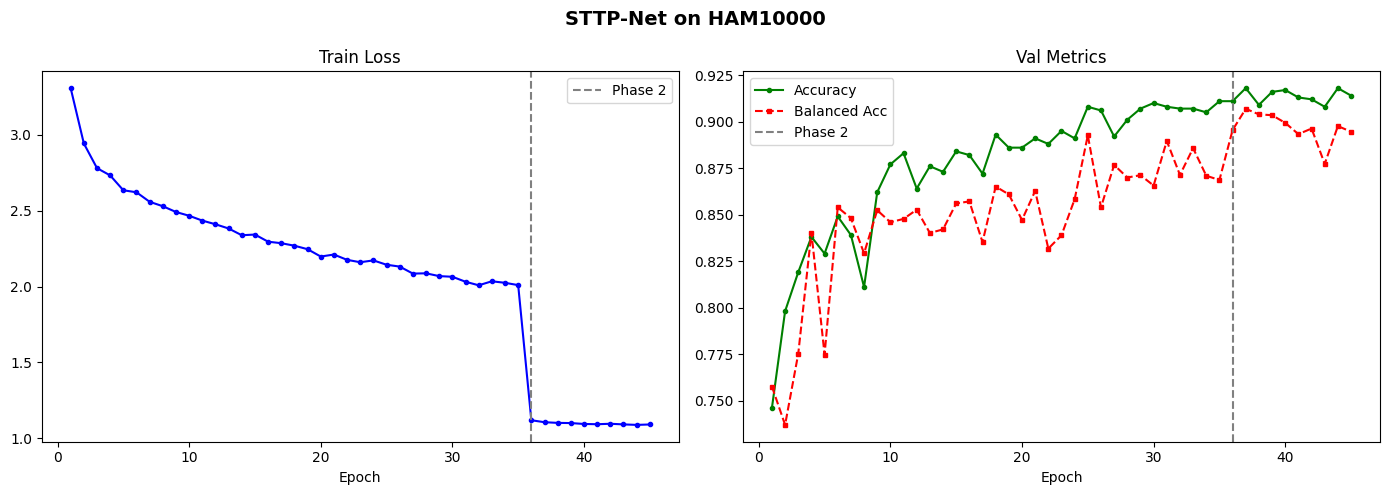

In [19]:
p2 = next((e for e,p in zip(history['epoch'],history['phase']) if p=='Boundary Refinement'), None)
fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].plot(history['epoch'], history['loss'], 'b-o', ms=3)
if p2: axes[0].axvline(p2, color='gray', ls='--', label='Phase 2')
axes[0].set_title('Train Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history['epoch'], history['val_acc'], 'g-o',  ms=3, label='Accuracy')
axes[1].plot(history['epoch'], history['val_bal'], 'r--s', ms=3, label='Balanced Acc')
if p2: axes[1].axvline(p2, color='gray', ls='--', label='Phase 2')
axes[1].set_title('Val Metrics'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.suptitle('STTP-Net on HAM10000', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'training_curves.png'), dpi=150)
plt.show()


## 14. Test Set Evaluation

In [20]:
model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
test_acc, test_bal, test_preds, test_labels, test_probs = evaluate_tta(model, test_loader, n_tta=5)

print(f'Test Accuracy          : {test_acc:.4f}')
print(f'Test Balanced Accuracy : {test_bal:.4f}\n')
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4))



Test Accuracy          : 0.9072
Test Balanced Accuracy : 0.8561

              precision    recall  f1-score   support

          nv     0.9583    0.9598    0.9590       671
         mel     0.7523    0.7321    0.7421       112
         bkl     0.7946    0.8091    0.8018       110
         bcc     0.9216    0.9038    0.9126        52
       akiec     0.7059    0.7500    0.7273        32
        vasc     0.9286    0.9286    0.9286        14
          df     1.0000    0.9091    0.9524        11

    accuracy                         0.9072      1002
   macro avg     0.8659    0.8561    0.8605      1002
weighted avg     0.9074    0.9072    0.9072      1002



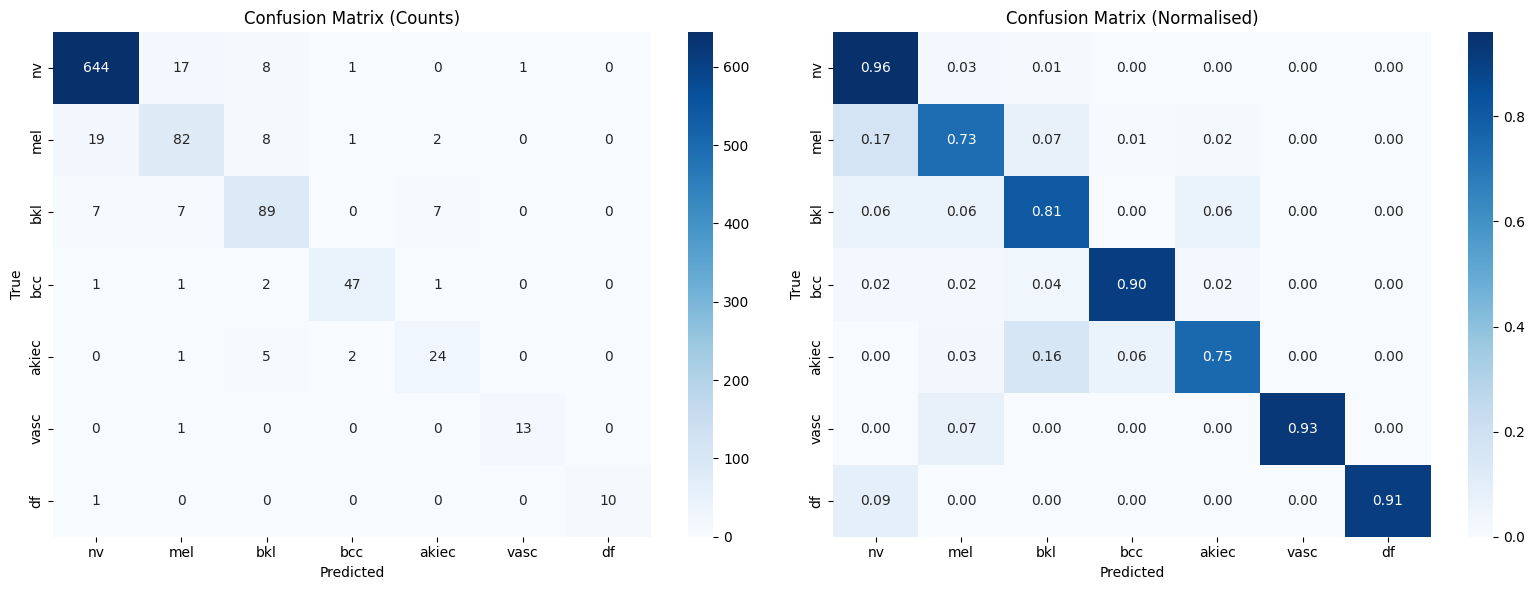

In [21]:
cm = confusion_matrix(test_labels, test_preds)
fig, axes = plt.subplots(1,2,figsize=(16,6))
for ax, data, title, fmt in zip(axes,
    [cm, cm.astype(float)/cm.sum(1,keepdims=True)],
    ['Counts','Normalised'], ['d','.2f']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'Confusion Matrix ({title})')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'confusion_matrix.png'), dpi=150)
plt.savefig(os.path.join(EXP_DIR, 'per_class_acc.png'), dpi=150)
plt.show()

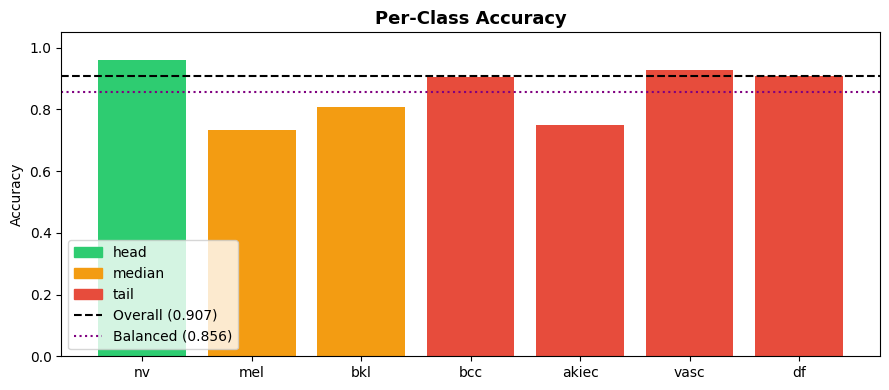

In [22]:
per = {IDX2LABEL[i]: (test_preds[test_labels==i]==i).mean()
       for i in range(NUM_CLASSES) if (test_labels==i).sum()>0}
fig, ax = plt.subplots(figsize=(9,4))
ax.bar(per.keys(), per.values(), color=[COLORS[CLASS_GROUPS[c]] for c in per])
ax.axhline(test_acc, color='black',  ls='--', label=f'Overall ({test_acc:.3f})')
ax.axhline(test_bal, color='purple', ls=':',  label=f'Balanced ({test_bal:.3f})')
ax.set_ylim(0,1.05); ax.set_ylabel('Accuracy')
ax.set_title('Per-Class Accuracy', fontsize=13, fontweight='bold')
ax.legend(handles=[Patch(color=v,label=k) for k,v in COLORS.items()]+[
    plt.Line2D([0],[0],color='black', ls='--',label=f'Overall ({test_acc:.3f})'),
    plt.Line2D([0],[0],color='purple',ls=':' ,label=f'Balanced ({test_bal:.3f})')
])
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR,'per_class_acc.png'), dpi=150)
plt.show()

## 15. Macro-AUC

In [23]:
try:
    auc = roc_auc_score(label_binarize(test_labels, classes=list(range(NUM_CLASSES))),
                        test_probs, multi_class='ovr', average='macro')
    print(f'Macro AUC: {auc:.4f}')
except Exception as e:
    print(f'AUC skipped: {e}')

Macro AUC: 0.9883


## 16. Latent Space Visualisation (t-SNE)

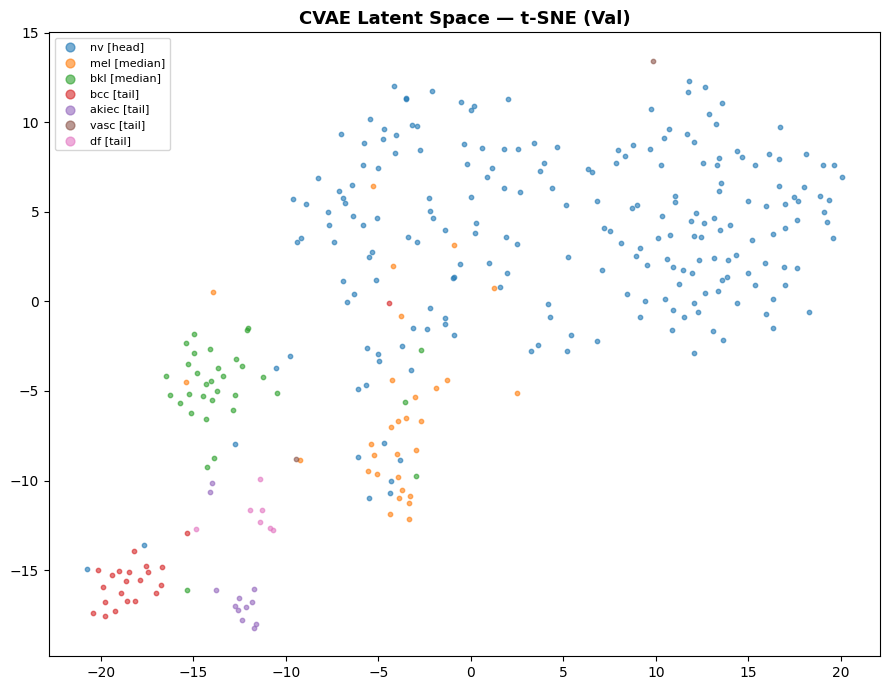

In [24]:
from sklearn.manifold import TSNE

@torch.no_grad()
def get_latents(loader, max_batches=20):
    model.eval()
    fs, ls = [], []
    for i,(imgs,lbl) in enumerate(loader):
        if i >= max_batches: break
        f = model.encoder(imgs.to(DEVICE))
        y = F.one_hot(lbl.to(DEVICE), NUM_CLASSES).float()
        mu,_ = model.cvae.encode(f, y)
        fs.append(mu.cpu().numpy()); ls.append(lbl.numpy())
    return np.concatenate(fs), np.concatenate(ls)

feats, lbls = get_latents(val_loader)
emb = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000).fit_transform(feats)

fig, ax = plt.subplots(figsize=(9,7))
cmap = plt.get_cmap('tab10')
for i, cls in IDX2LABEL.items():
    m = lbls==i
    ax.scatter(emb[m,0], emb[m,1], label=f'{cls} [{CLASS_GROUPS[cls]}]',
               alpha=0.6, s=10, color=cmap(i))
ax.set_title('CVAE Latent Space — t-SNE (Val)', fontsize=13, fontweight='bold')
ax.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'tsne_latent.png'), dpi=150)
plt.show()

## 17. Single Image Inference

In [22]:
def predict(image_path):
    model.eval()
    img = Image.open(image_path).convert('RGB')
    with torch.no_grad():
        p = F.softmax(model.fused_logits(eval_transform(img).unsqueeze(0).to(DEVICE)),-1).squeeze().cpu().numpy()
    res = {c: float(v) for c,v in zip(CLASS_NAMES, p)}
    pred = max(res, key=res.get)
    fig, axes = plt.subplots(1,2,figsize=(10,4))
    axes[0].imshow(img); axes[0].axis('off'); axes[0].set_title('Input')
    axes[1].barh(CLASS_NAMES, [res[c] for c in CLASS_NAMES],
                 color=[COLORS[CLASS_GROUPS[c]] for c in CLASS_NAMES])
    axes[1].set_xlim(0,1)
    axes[1].set_title(f'{pred}  ({res[pred]:.1%})')
    plt.tight_layout(); plt.show()
    return res

# Usage — update path and uncomment:
# predict(r'D:\class imbalance\date-16\data\raw\images\ISIC_0024306.jpg')
print('predict() ready.')

predict() ready.


## 18. Save Results

In [26]:
out = {
    'test_accuracy':          round(float(test_acc), 4),
    'test_balanced_accuracy': round(float(test_bal), 4),
    'best_val_balanced_acc':  round(best_bal, 4),
    'class_groups':           CLASS_GROUPS,
    'architecture':           'ResNet50 + CVAE + SupCon + HybridMix + DualHead + EBS',
    'phases': {
        'phase1': f'{EPOCHS_PHASE1} epochs HybridMix',
        'phase2': f'{EPOCHS_PHASE2} epochs Boundary Refinement'
    },
}
path = os.path.join(EXP_DIR, 'results_summary.json')
with open(path, 'w') as f:
    json.dump(out, f, indent=2)
print('Saved:', path)
print(json.dumps(out, indent=2))

Saved: D:\class imbalance\date-16\experiments\exp03_medical_aug\results_summary.json
{
  "test_accuracy": 0.8084,
  "test_balanced_accuracy": 0.7611,
  "best_val_balanced_acc": 0.8903,
  "class_groups": {
    "nv": "head",
    "mel": "median",
    "bkl": "median",
    "bcc": "tail",
    "akiec": "tail",
    "vasc": "tail",
    "df": "tail"
  },
  "architecture": "ResNet50 + CVAE + SupCon + HybridMix + DualHead + EBS",
  "phases": {
    "phase1": "40 epochs HybridMix",
    "phase2": "15 epochs Boundary Refinement"
  }
}
